In [ ]:
!unzip '/content/archive (4).zip'

Archive:  /content/archive (4).zip
  inflating: CleavageEmbryov1.1/CleavageEmbryov1.1/annotations/instances_train.json  
  inflating: CleavageEmbryov1.1/CleavageEmbryov1.1/annotations/instances_val.json  
  inflating: CleavageEmbryov1.1/CleavageEmbryov1.1/images/train/20230304-17097-10-FX0-217.jpg  
  inflating: CleavageEmbryov1.1/CleavageEmbryov1.1/images/train/20230304-17097-10-FX0-219.jpg  
  inflating: CleavageEmbryov1.1/CleavageEmbryov1.1/images/train/20230304-17097-10-FX0-221.jpg  
  inflating: CleavageEmbryov1.1/CleavageEmbryov1.1/images/train/20230304-17097-3-F0-158.jpg  
  inflating: CleavageEmbryov1.1/CleavageEmbryov1.1/images/train/20230304-17097-3-F0-159.jpg  
  inflating: CleavageEmbryov1.1/CleavageEmbryov1.1/images/train/20230304-17097-3-F0-173.jpg  
  inflating: CleavageEmbryov1.1/CleavageEmbryov1.1/images/train/20230304-17097-3-F0-176.jpg  
  inflating: CleavageEmbryov1.1/CleavageEmbryov1.1/images/train/20230304-17097-3-F0-177.jpg  
  inflating: CleavageEmbryov1.1/Cleav

In [ ]:
!pip install ultralytics
!pip install pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.0 MB/s eta 0:00:00


In [ ]:
import torch
print("GPU available:" , torch.cuda.is_available())

GPU available: True


In [ ]:
from ultralytics import YOLO
import os

# 1. JSON se YOLO format mein conversion (Automated)
from ultralytics.data.converter import convert_coco

# Annotation files ka path
json_dir = "/content/CleavageEmbryov1.1/CleavageEmbryov1.1/annotations/"

# Ye command JSON ko TXT mein badal degi
convert_coco(labels_dir=json_dir)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Annotations /content/CleavageEmbryov1.1/CleavageEmbryov1.1/annotations/instances_train.json: 100% ━━━━━━━━━━━━ 1232/1232 4.5Kit/s 0.3s
Annotations /content/CleavageEmbryov1.1/CleavageEmbryov1.1/annotations/instances_val.json: 100% ━━━━━━━━━━━━ 316/316 4.9Kit/s 0.1s
COCO data converted successfully.
Results saved to /content/coco_converted


In [ ]:
yaml_content = """
path: /content/CleavageEmbryov1.1/CleavageEmbryov1.1/  # root path
train: images/train  # train images
val: images/val      # val images

# Classes
names:
  0: cell  # Aapki JSON file mein jo bhi class name hai
"""

with open('data.yaml', 'w') as f:
    f.write(yaml_content)

In [ ]:
import json
import os

# 1. Folders banayein jahan labels jayenge
os.makedirs('/content/CleavageEmbryov1.1/CleavageEmbryov1.1/labels/train', exist_ok=True)
os.makedirs('/content/CleavageEmbryov1.1/CleavageEmbryov1.1/labels/val', exist_ok=True)

def convert_to_yolo(json_path, output_labels_dir):
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Images ki info save karein
    images = {img['id']: img for img in data['images']}

    for ann in data['annotations']:
        img_id = ann['image_id']
        img_info = images[img_id]
        w, h = img_info['width'], img_info['height']

        # COCO (x, y, width, height) to YOLO (center_x, center_y, width, height) normalized
        bbox = ann['bbox']
        x_center = (bbox[0] + bbox[2] / 2) / w
        y_center = (bbox[1] + bbox[3] / 2) / h
        width = bbox[2] / w
        height = bbox[3] / h

        # Label file ka naam (image name ke mutabiq)
        label_name = os.path.splitext(img_info['file_name'])[0] + ".txt"
        label_path = os.path.join(output_labels_dir, label_name)

        # Write to file (Class ID hamesha 0 rakhein agar ek hi class hai)
        with open(label_path, 'a') as f_out:
            f_out.write(f"0 {x_center} {y_center} {width} {height}\n")

# 2. Dono files ko convert karein
convert_to_yolo('/content/CleavageEmbryov1.1/CleavageEmbryov1.1/annotations/instances_train.json',
                '/content/CleavageEmbryov1.1/CleavageEmbryov1.1/labels/train')

convert_to_yolo('/content/CleavageEmbryov1.1/CleavageEmbryov1.1/annotations/instances_val.json',
                '/content/CleavageEmbryov1.1/CleavageEmbryov1.1/labels/val')

print("Done! Labels convert ho gaye hain.")

Done! Labels convert ho gaye hain.


In [ ]:
from ultralytics import YOLO
import os

In [ ]:
from ultralytics import YOLO

# Model load karein
model = YOLO('yolov8n.pt')

# Training start with 50 epochs
model.train(data='data.yaml', epochs=50, imgsz=640, device=0)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7978ac14e600>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
# Sahi path dein jahan last.pt pari hai
model = YOLO('/content/runs/detect/train2/weights/last.pt')

# Resume command chalaein
model.train(resume=True)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/train2/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dcfec7ea300>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from ultralytics import YOLO
import glob
import matplotlib.pyplot as plt
import cv2

# Best model load karein
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Validation images par prediction chalayein
results = model.predict(source='/content/CleavageEmbryov1.1/CleavageEmbryov1.1/images/val', save=True, conf=0.5)

# Ek do results dekhne ke liye (runs/detect/predict/ mein save honge)
# Aap Files panel se predict folder mein ja kar images open kar sakte hain.


image 1/316 /content/CleavageEmbryov1.1/CleavageEmbryov1.1/images/val/20230304-17097-10-FX0-216.jpg: 640x640 8 cells, 11.9ms
image 2/316 /content/CleavageEmbryov1.1/CleavageEmbryov1.1/images/val/20230304-17097-10-FX0-218.jpg: 640x640 8 cells, 35.4ms
image 3/316 /content/CleavageEmbryov1.1/CleavageEmbryov1.1/images/val/20230304-17097-3-F0-157.jpg: 640x640 15 cells, 20.8ms
image 4/316 /content/CleavageEmbryov1.1/CleavageEmbryov1.1/images/val/20230304-17097-3-F0-174.jpg: 640x640 6 cells, 27.8ms
image 5/316 /content/CleavageEmbryov1.1/CleavageEmbryov1.1/images/val/20230304-17097-3-F0-175.jpg: 640x640 6 cells, 19.7ms
image 6/316 /content/CleavageEmbryov1.1/CleavageEmbryov1.1/images/val/20230304-17097-3-F0-228.jpg: 640x640 7 cells, 20.4ms
image 7/316 /content/CleavageEmbryov1.1/CleavageEmbryov1.1/images/val/20230304-17097-3-F0-252.jpg: 640x640 9 cells, 36.2ms
image 8/316 /content/CleavageEmbryov1.1/CleavageEmbryov1.1/images/val/20230304-17097-3-F0-254.jpg: 640x640 10 cells, 27.3ms
image 9/3


image 1/1 /content/CleavageEmbryov1.1/CleavageEmbryov1.1/images/val/D2024.06.01_S00698_I4778_P_WELL01_RUN303.jpg: 640x640 9 cells, 7.2ms
Speed: 2.8ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


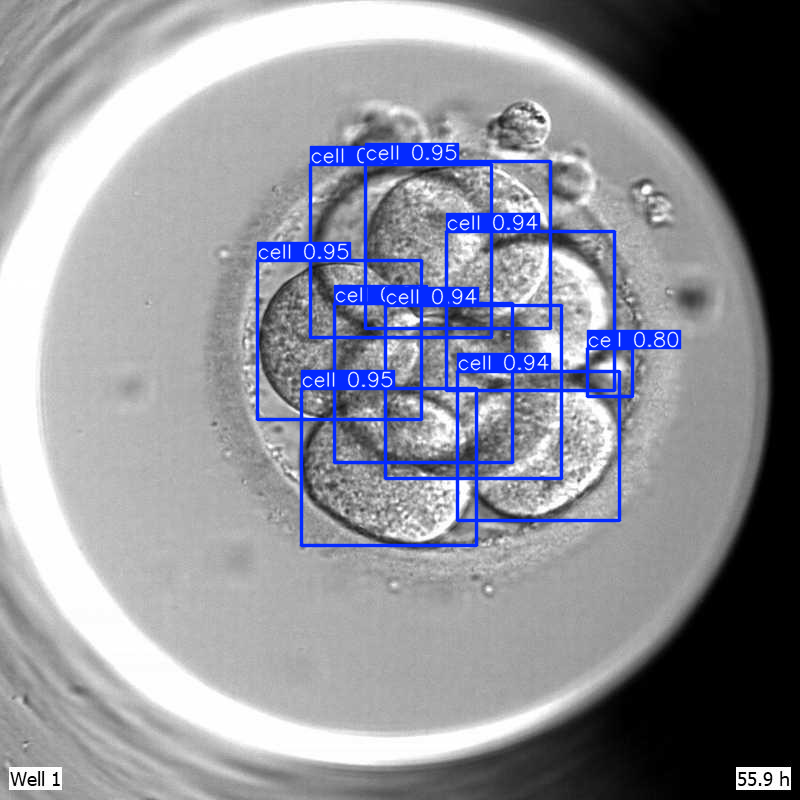

In [ ]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 1. Model ko batayein ke kahan para hai
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Kisi bhi ek image ka path dein aur "predict" karein
# Hum validation folder se ek image utha rahe hain
results = model.predict(source='/content/CleavageEmbryov1.1/CleavageEmbryov1.1/images/val/D2024.06.01_S00698_I4778_P_WELL01_RUN303.jpg', conf=0.5)

# 3. Result ko screen par dikha dein
res_img = results[0].plot()
cv2_imshow(res_img)